# 02 — Surface Visualization

Visualize implied volatility surfaces and their 6 channels (IV, spread, mask, staleness,
delta, vega). Shows both individual surfaces and temporal evolution.

**Prerequisites:** Run `make surfaces` so that `data/liquid_core/processed/` is populated.

In [28]:
import sys
from pathlib import Path
import os
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

from volregime.utils.config import load_config

cfg = load_config()
# Use the correct data path
data_dir = Path('data/liquid_core')
processed_dir = data_dir / 'processed'

# Surface grid config
surf_cfg = cfg['data']['surface']
n_maturity  = surf_cfg['n_maturity_bins']    # 12
n_moneyness = surf_cfg['n_moneyness_bins']   # 20
maturity_buckets = surf_cfg['maturity_buckets']
moneyness_min = cfg['data']['moneyness']['min']
moneyness_max = cfg['data']['moneyness']['max']

# Axes for plots
log_m_edges   = np.linspace(np.log(moneyness_min), np.log(moneyness_max), n_moneyness + 1)
log_m_centers = (log_m_edges[:-1] + log_m_edges[1:]) / 2
moneyness_centers = np.exp(log_m_centers)
maturity_labels = [f"{d}d" for d in maturity_buckets]

CHANNEL_NAMES = ['IV', 'Spread', 'Mask', 'Staleness', 'Delta', 'Vega']

print(f"n_maturity={n_maturity}, n_moneyness={n_moneyness}")
print(f"processed_dir exists: {processed_dir.exists()}")

n_maturity=12, n_moneyness=20
processed_dir exists: True


In [29]:
# Load sample index and a few surfaces
sample_idx_path = processed_dir / 'sample_index.parquet'
if not sample_idx_path.exists():
    raise FileNotFoundError(f"sample_index.parquet not found at {sample_idx_path}. Run `make surfaces` first.")

sample_index = pd.read_parquet(sample_idx_path)
print(f"Total samples: {len(sample_index):,}")

# Pick a symbol and sort by date
symbol = sample_index['symbol'].value_counts().idxmax()
sym_idx = sample_index[sample_index['symbol'] == symbol].copy()
sym_idx = sym_idx.sort_values('date').reset_index(drop=True)
print(f"Using {symbol}: {len(sym_idx)} samples")

def load_surface(date, sym):
    p = processed_dir / 'surfaces' / sym / f"{date}.pt"
    if p.exists():
        return torch.load(p, weights_only=True).numpy()
    return None

Total samples: 25,783
Using MSFT: 2795 samples


## 1. Single Surface — All 6 Channels

Date: 2016-02-17, Symbol: MSFT, Shape: (6, 12, 20)


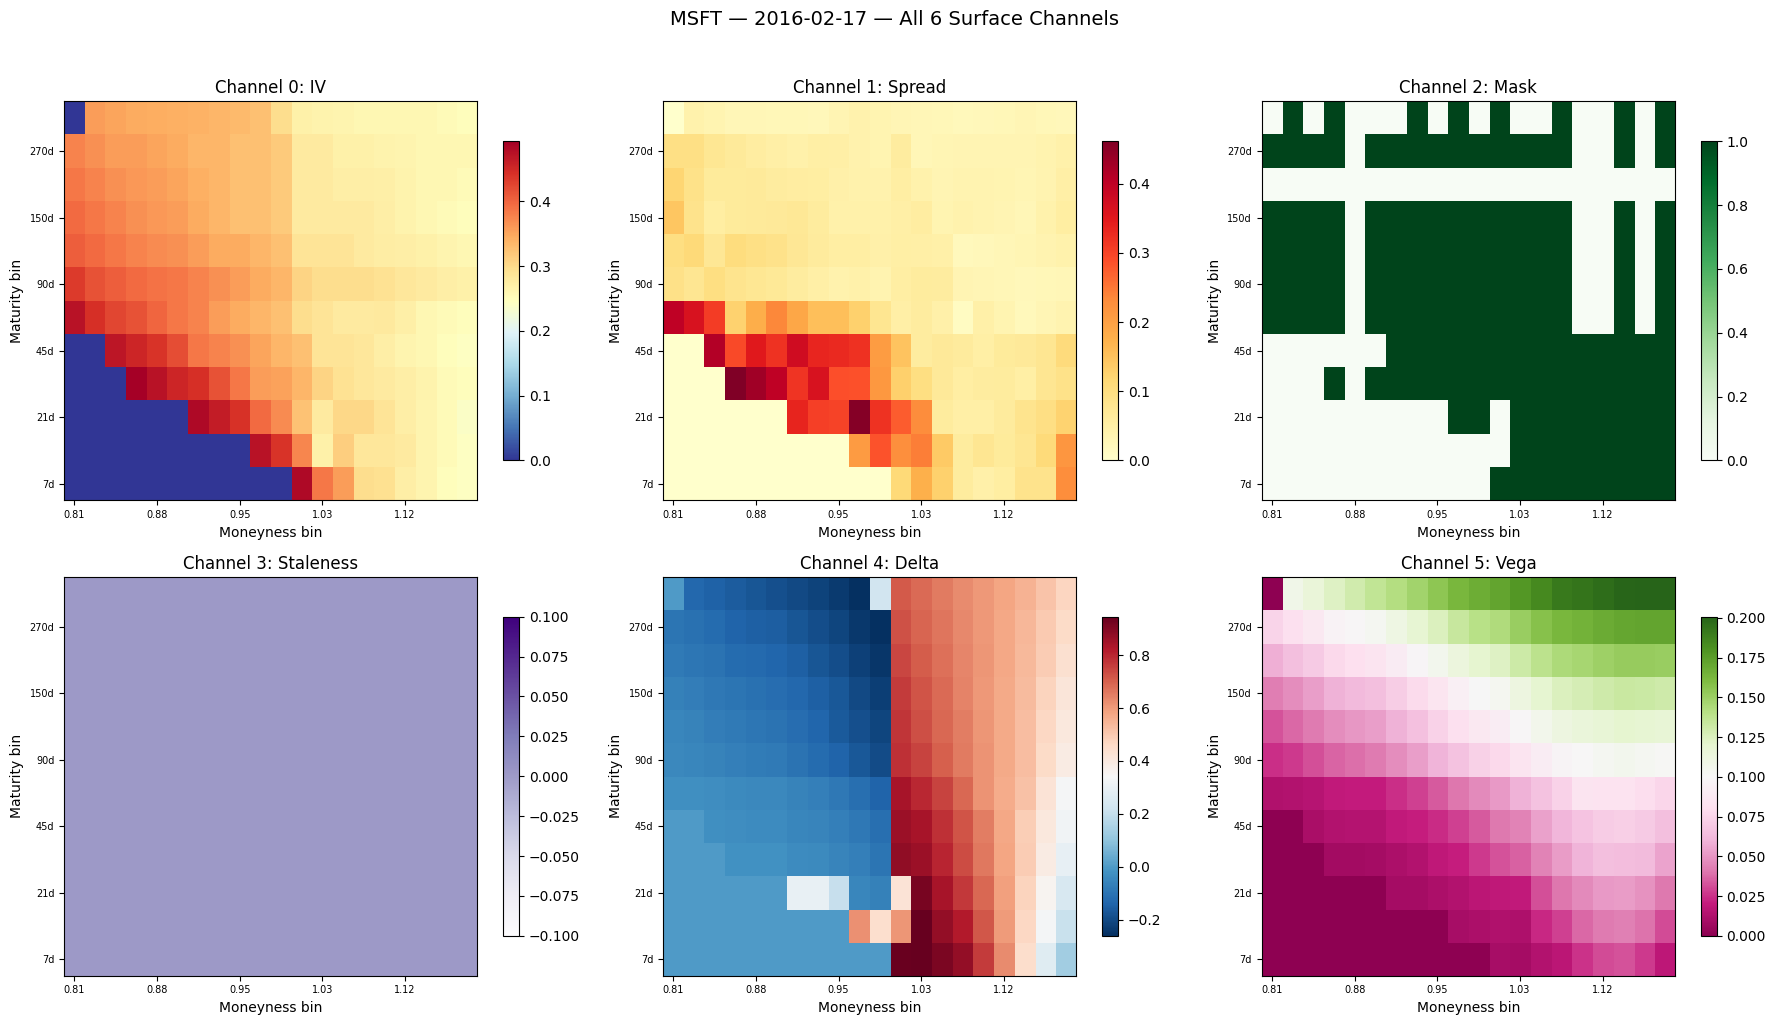

In [30]:
# Find the sample with richest observation density
best_idx, best_density = 0, 0
best_surface = None
for i in range(min(500, len(sym_idx))):
    row_i = sym_idx.iloc[i]
    s = load_surface(row_i['date'], row_i['symbol'])
    if s is not None and s[2].mean() > best_density:
        best_density = s[2].mean()
        best_idx = i
        best_surface = s

row = sym_idx.iloc[best_idx]
surface = best_surface if best_surface is not None else load_surface(row['date'], row['symbol'])

if surface is None:
    print(f"Warning: Could not load surface for {row['date']}, {row['symbol']}. Trying next sample...")
    # Find first available surface
    for i in range(len(sym_idx)):
        row_i = sym_idx.iloc[i]
        s = load_surface(row_i['date'], row_i['symbol'])
        if s is not None:
            row = row_i
            surface = s
            break

if surface is not None:
    print(f"Date: {row['date']}, Symbol: {row['symbol']}, Shape: {surface.shape}")
else:
    print("Error: No valid surfaces found. Ensure `make surfaces` has been run.")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cmaps = ['RdYlBu_r', 'YlOrRd', 'Greens', 'Purples', 'RdBu_r', 'PiYG']

for i, (ax, cmap, name) in enumerate(zip(axes.flat, cmaps, CHANNEL_NAMES)):
    channel = surface[i]
    im = ax.imshow(channel, aspect='auto', cmap=cmap, origin='lower')
    ax.set_title(f'Channel {i}: {name}', fontsize=12)
    ax.set_xlabel('Moneyness bin')
    ax.set_ylabel('Maturity bin')

    xtick_pos = np.arange(0, n_moneyness, 4)
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels([f"{moneyness_centers[j]:.2f}" for j in xtick_pos], fontsize=7)
    ytick_pos = np.arange(0, n_maturity, 2)
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels([maturity_labels[j] for j in ytick_pos], fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'{symbol} — {row["date"]} — All 6 Surface Channels', fontsize=14, y=1.02)
plt.tight_layout()

## 2. IV Surface as 3D Plot

In [31]:
import plotly.graph_objects as go
from scipy.interpolate import griddata

iv_channel = surface[0]   # (12, 20)
mask_channel = surface[2]

M, T = np.meshgrid(moneyness_centers, maturity_buckets)

# Interpolate missing grid points for a smooth continuous surface
obs_mask = mask_channel > 0
points   = np.column_stack([M[obs_mask], T[obs_mask]])
values   = iv_channel[obs_mask]
iv_interp = griddata(points, values, (M, T), method='linear')
# Fall back to nearest for any remaining NaNs at the boundary
iv_nearest = griddata(points, values, (M, T), method='nearest')
iv_full = np.where(np.isnan(iv_interp), iv_nearest, iv_interp)

# Overlay: NaN where not observed (shown as transparent holes on top surface)
iv_observed = np.where(obs_mask, iv_channel, np.nan)

fig = go.Figure()

# Full interpolated surface (base)
fig.add_trace(go.Surface(
    x=M, y=T, z=iv_full,
    colorscale='RdYlBu_r',
    opacity=0.75,
    showscale=True,
    colorbar=dict(title='IV', thickness=15),
    name='Interpolated',
    hovertemplate='Moneyness: %{x:.3f}<br>Maturity: %{y}d<br>IV: %{z:.4f}<extra>interpolated</extra>',
))

# Observed-only surface on top (solid)
fig.add_trace(go.Surface(
    x=M, y=T, z=iv_observed,
    colorscale='RdYlBu_r',
    opacity=1.0,
    showscale=False,
    name='Observed',
    hovertemplate='Moneyness: %{x:.3f}<br>Maturity: %{y}d<br>IV: %{z:.4f}<extra>observed</extra>',
))

obs_pct = obs_mask.mean() * 100
fig.update_layout(
    title=dict(
        text=f'{symbol} — {row["date"]} — IV Surface  ({obs_pct:.0f}% observed, remainder interpolated)',
        x=0.5, font=dict(size=14),
    ),
    scene=dict(
        xaxis=dict(title='Moneyness (K/S)'),
        yaxis=dict(title='Maturity (days)'),
        zaxis=dict(title='Implied Volatility'),
        camera=dict(eye=dict(x=1.7, y=-1.5, z=0.9)),
        aspectratio=dict(x=1.4, y=1.2, z=0.8),
    ),
    width=950, height=680,
    margin=dict(l=0, r=0, t=60, b=0),
)

fig.show()

## 3. Volatility Smile Slices (Fixed Maturity)

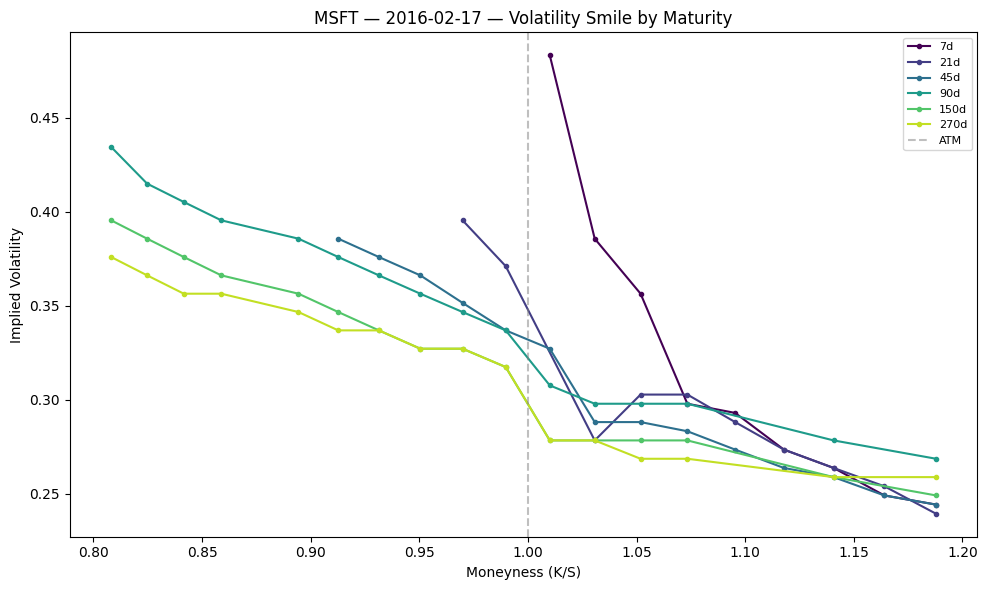

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, n_maturity))

for t_idx in range(0, n_maturity, 2):
    iv_slice   = iv_channel[t_idx, :]
    mask_slice = mask_channel[t_idx, :]
    valid = mask_slice > 0
    if valid.sum() > 2:
        ax.plot(moneyness_centers[valid], iv_slice[valid],
                marker='o', ms=3, color=colors[t_idx],
                label=f'{maturity_buckets[t_idx]}d')

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title(f'{symbol} — {row["date"]} — Volatility Smile by Maturity')
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.legend(fontsize=8)
plt.tight_layout()

## 4. Term Structure Slices (Fixed Moneyness)

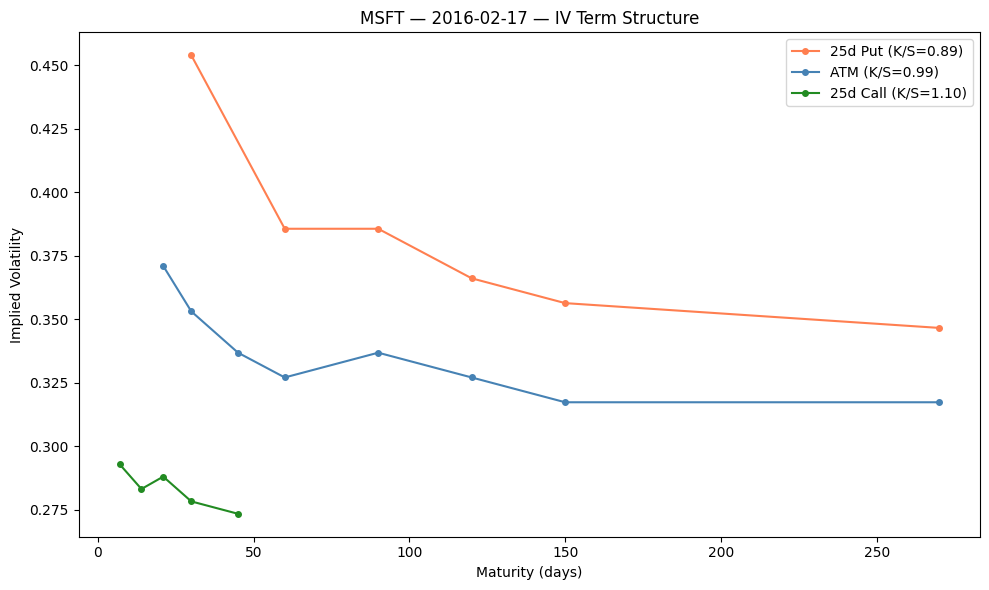

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

atm_col  = n_moneyness // 2
put_col  = n_moneyness // 4
call_col = 3 * n_moneyness // 4

slices = [
    (put_col,  f'25d Put (K/S={moneyness_centers[put_col]:.2f})',  'coral'),
    (atm_col,  f'ATM (K/S={moneyness_centers[atm_col]:.2f})',      'steelblue'),
    (call_col, f'25d Call (K/S={moneyness_centers[call_col]:.2f})', 'forestgreen'),
]

for m_idx, label, color in slices:
    term = iv_channel[:, m_idx]
    mask = mask_channel[:, m_idx]
    valid = mask > 0
    if valid.sum() > 1:
        ax.plot(np.array(maturity_buckets)[valid], term[valid],
                marker='o', ms=4, color=color, label=label)

ax.set_xlabel('Maturity (days)')
ax.set_ylabel('Implied Volatility')
ax.set_title(f'{symbol} — {row["date"]} — IV Term Structure')
ax.legend()
plt.tight_layout()

## 5. Surface Evolution Over Time

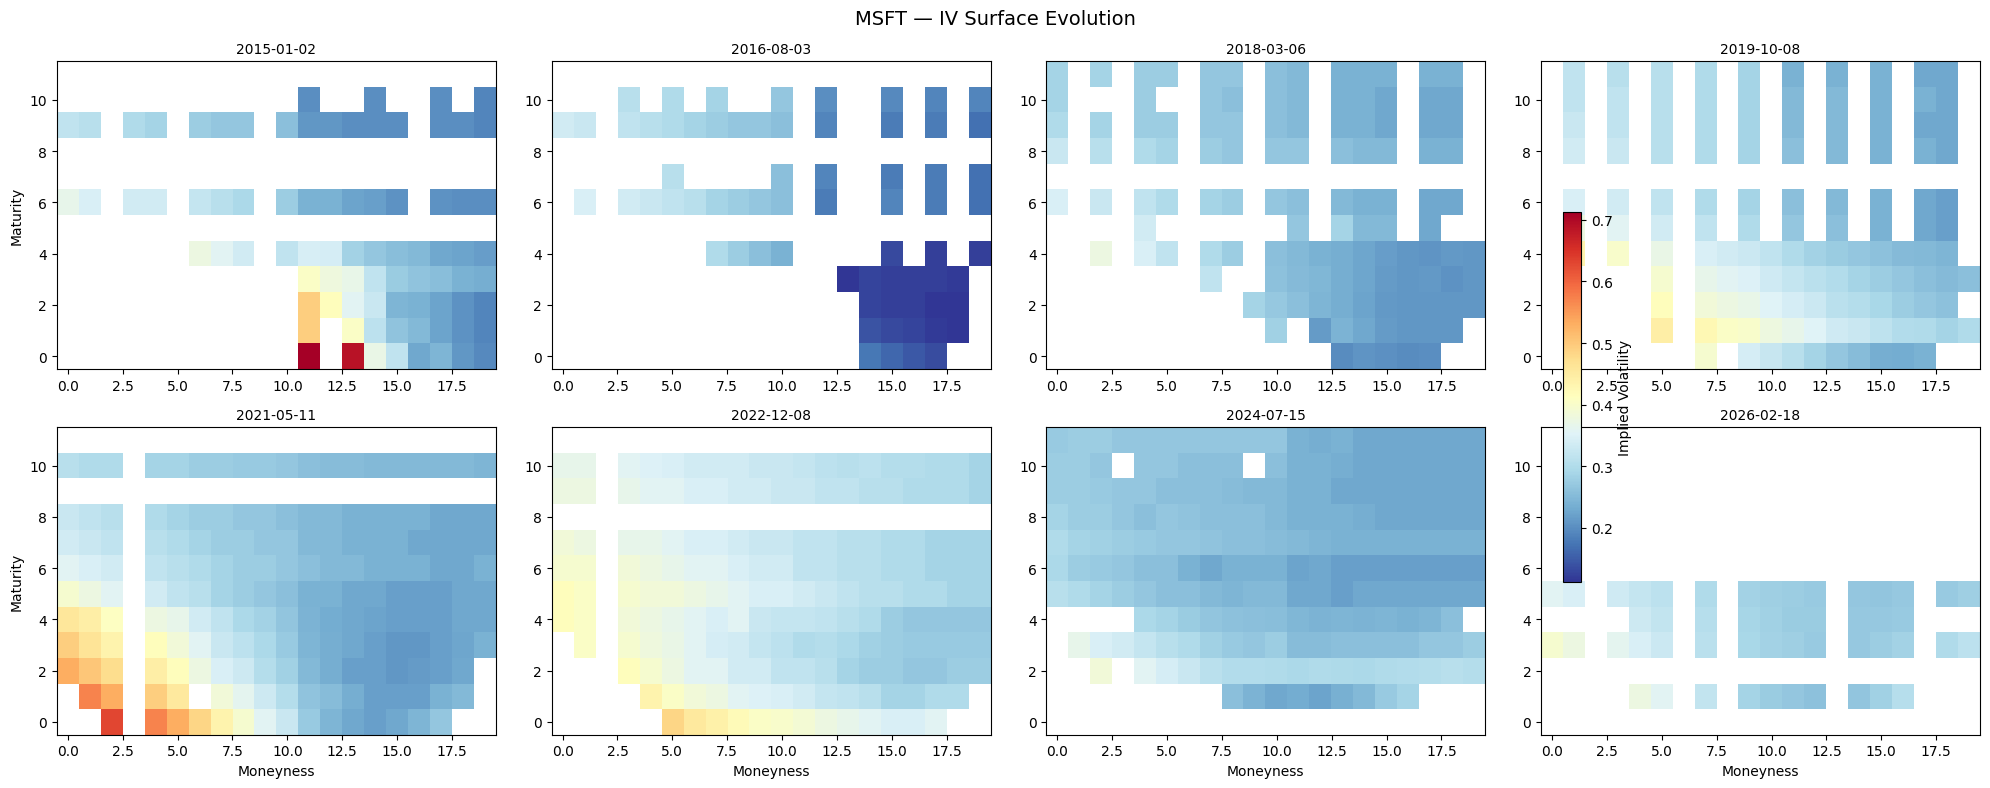

In [34]:
n_snapshots = 8
indices = np.linspace(0, len(sym_idx) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Compute global vmin/vmax
all_ivs = []
for idx in indices:
    row_i = sym_idx.iloc[idx]
    s = load_surface(row_i['date'], row_i['symbol'])
    if s is not None:
        observed = s[0][s[2] > 0]
        if len(observed) > 0:
            all_ivs.append(observed)

if all_ivs:
    vmin = min(arr.min() for arr in all_ivs)
    vmax = max(arr.max() for arr in all_ivs)
else:
    vmin, vmax = 0, 1

for ax_idx, data_idx in enumerate(indices):
    row_i = sym_idx.iloc[data_idx]
    s = load_surface(row_i['date'], row_i['symbol'])
    if s is None:
        continue
    iv = np.where(s[2] > 0, s[0], np.nan)

    ax = axes.flat[ax_idx]
    im = ax.imshow(iv, aspect='auto', cmap='RdYlBu_r', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(str(row_i['date']), fontsize=10)
    if ax_idx % 4 == 0:
        ax.set_ylabel('Maturity')
    if ax_idx >= 4:
        ax.set_xlabel('Moneyness')

fig.colorbar(im, ax=axes, shrink=0.6, label='Implied Volatility')
plt.suptitle(f'{symbol} — IV Surface Evolution', fontsize=14)
plt.tight_layout()

## 6. ATM Vol and Skew Time Series

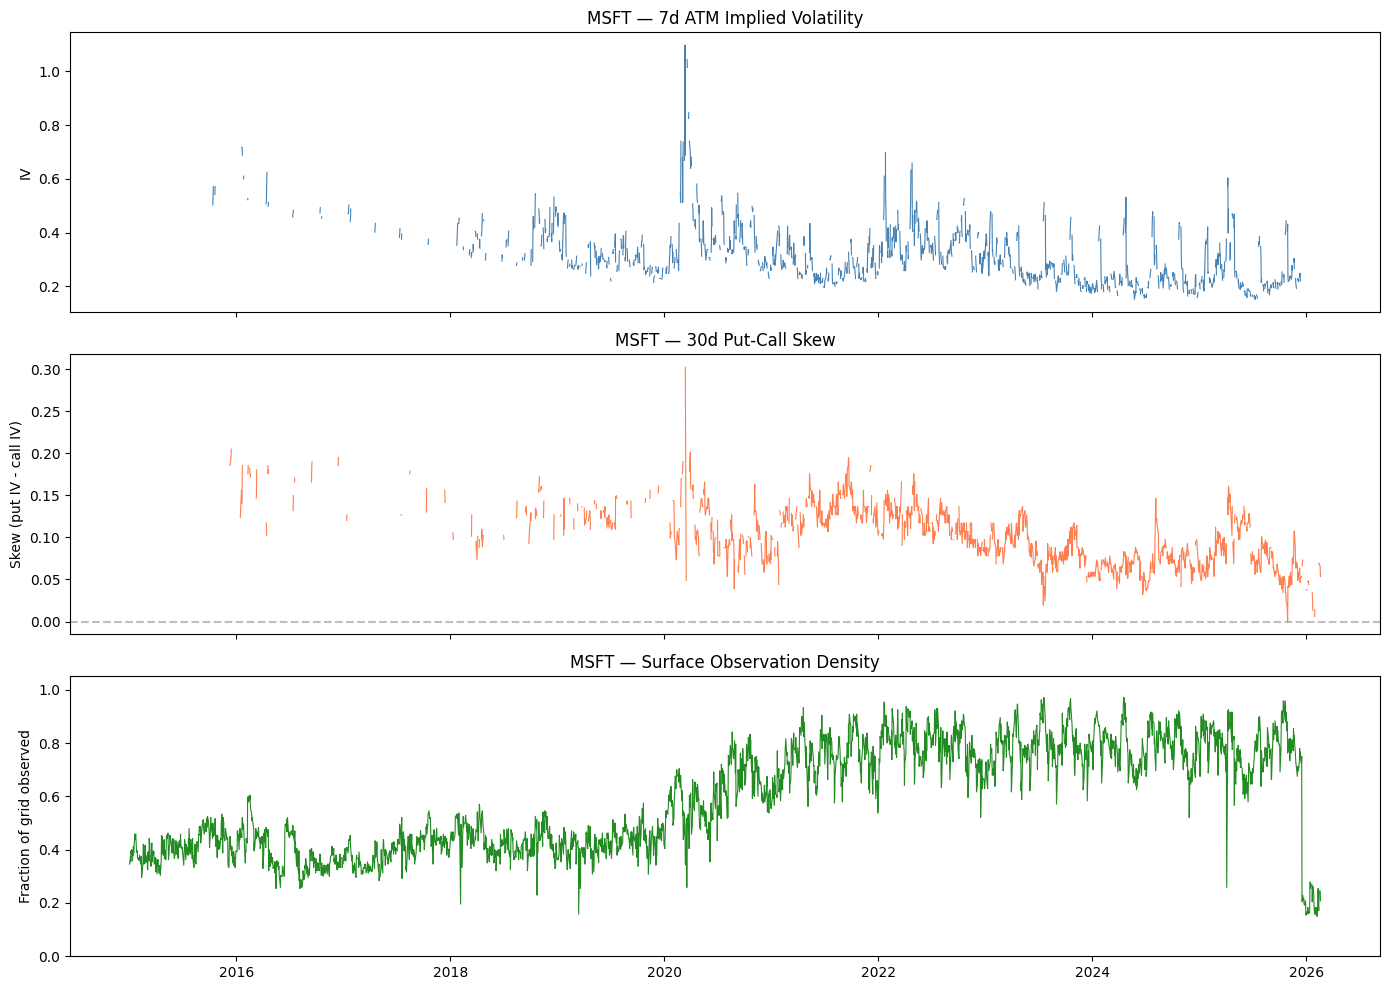

In [35]:
atm_vols = []
skews = []
dates = []
obs_densities = []

atm_col  = n_moneyness // 2
put_col  = n_moneyness // 4
call_col = 3 * n_moneyness // 4

for i in range(len(sym_idx)):
    row_i = sym_idx.iloc[i]
    s = load_surface(row_i['date'], row_i['symbol'])
    if s is None:
        continue
    iv, mask = s[0], s[2]

    # ATM vol: shortest maturity, center moneyness
    atm_v = iv[0, atm_col] if mask[0, atm_col] > 0 else np.nan

    # Skew: 25d put - 25d call at ~30d maturity (index 3)
    mat_idx = min(3, n_maturity - 1)
    put_v  = iv[mat_idx, put_col]  if mask[mat_idx, put_col] > 0  else np.nan
    call_v = iv[mat_idx, call_col] if mask[mat_idx, call_col] > 0 else np.nan
    skew = (put_v - call_v) if not (np.isnan(put_v) or np.isnan(call_v)) else np.nan

    atm_vols.append(atm_v)
    skews.append(skew)
    dates.append(row_i['date'])
    obs_densities.append(mask.mean())

dates_ts = pd.to_datetime(dates)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dates_ts, atm_vols, color='steelblue', lw=0.8)
axes[0].set_title(f'{symbol} — 7d ATM Implied Volatility')
axes[0].set_ylabel('IV')

axes[1].plot(dates_ts, skews, color='coral', lw=0.8)
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[1].set_title(f'{symbol} — 30d Put-Call Skew')
axes[1].set_ylabel('Skew (put IV - call IV)')

axes[2].plot(dates_ts, obs_densities, color='forestgreen', lw=0.8)
axes[2].set_title(f'{symbol} — Surface Observation Density')
axes[2].set_ylabel('Fraction of grid observed')
axes[2].set_ylim(0, 1.05)

plt.tight_layout()

## 7. Delta and Vega Surfaces

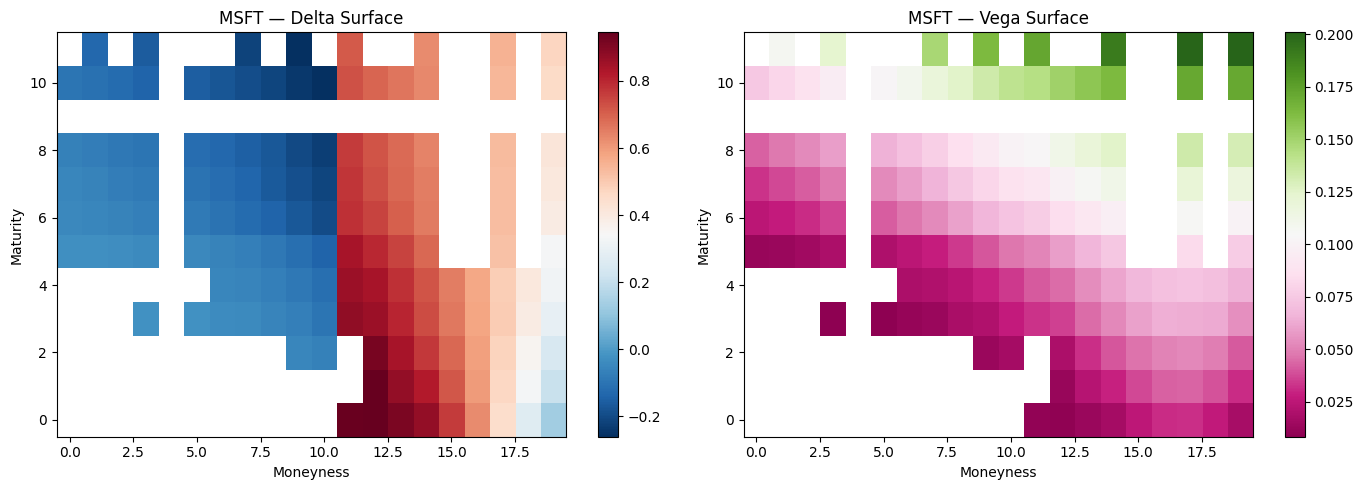

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delta_ch = np.where(mask_channel > 0, surface[4], np.nan)
vega_ch  = np.where(mask_channel > 0, surface[5], np.nan)

im0 = axes[0].imshow(delta_ch, aspect='auto', cmap='RdBu_r', origin='lower')
axes[0].set_title(f'{symbol} — Delta Surface')
axes[0].set_xlabel('Moneyness')
axes[0].set_ylabel('Maturity')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(vega_ch, aspect='auto', cmap='PiYG', origin='lower')
axes[1].set_title(f'{symbol} — Vega Surface')
axes[1].set_xlabel('Moneyness')
axes[1].set_ylabel('Maturity')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()